In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/parking_violations_india.csv")

In [4]:
df.head()

,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [5]:
df.describe()

,latitude,longitude,description,closed_datetime,center_code,action_taken_timestamp
count,298450.000000,298450.000000,0.0,0.0,287190.000000,0.0
mean,12.980802,77.600512,NaN,NaN,23.023013,NaN
std,0.049732,0.050518,NaN,NaN,20.006118,NaN
min,12.802667,77.442553,NaN,NaN,2.000000,NaN
25%,12.963331,77.571198,NaN,NaN,11.000000,NaN
50%,12.977284,77.584114,NaN,NaN,17.000000,NaN
75%,12.997467,77.621529,NaN,NaN,29.000000,NaN
max,13.293684,77.771735,NaN,NaN,88.000000,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4   vehicle_number                298450 non-null  object 
 5   vehicle_type                  298450 non-null  object 
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  object 
 8   offence_code                  298450 non-null  object 
 9   created_datetime              298450 non-null  object 
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  object 
 12  device_id                     298450 non-nul

In [7]:
df.isnull().sum()

id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64

## 1. Data Cleaning, Parsing & Traffic Obstruction Score (TOS) Calculation
We parse the mixed-format timestamps, parse the json lists of violations, and calculate the **Traffic Obstruction Score (TOS)** for each record using our weight metrics.

In [8]:
# Parse datetime columns (handling mixed ISO formats)
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='mixed')

# Safe literal parsing for JSON-like string arrays
import ast
def safe_parse(val):
    if pd.isna(val) or val == 'NULL' or val == '':
        return []
    try:
        return ast.literal_eval(val)
    except Exception:
        return [x.strip('[]"\' ') for x in val.split(',')]

df['parsed_violations'] = df['violation_type'].apply(safe_parse)
df['parsed_offences'] = df['offence_code'].apply(safe_parse)

# Define Weights for TOS Calculation
def get_vehicle_weight(vt):
    vt_upper = str(vt).upper()
    if any(w in vt_upper for w in ['TANKER', 'BUS', 'TRUCK', 'LIVESTOCK', 'HEAVY']):
        return 5.0
    elif any(w in vt_upper for w in ['CAR', 'SUV', 'MAXI-CAB', 'TEMPO', 'JEEP']):
        return 3.0
    elif any(w in vt_upper for w in ['AUTO', 'THREE WHEELER', 'PASSENGER AUTO']):
        return 2.0
    else:
        return 1.0  # SCOOTER, TWO WHEELER, etc.

def get_violation_weight(violations):
    if not violations:
        return 2.0
    high_impact_keywords = ['CROSSING', 'MAIN ROAD', 'DOUBLE PARKING', 'FOOTPATH', 'CORNER']
    weight = 2.0
    for v in violations:
        v_upper = str(v).upper()
        if any(kw in v_upper for kw in high_impact_keywords):
            weight = 4.0
            break
    return weight

df['vehicle_weight'] = df['vehicle_type'].apply(get_vehicle_weight)
df['violation_weight'] = df['parsed_violations'].apply(get_violation_weight)
df['junction_multiplier'] = df['junction_name'].apply(lambda x: 1.5 if pd.notna(x) and x != 'No Junction' else 1.0)

# Calculate the target score
df['TOS'] = (df['vehicle_weight'] + df['violation_weight']) * df['junction_multiplier']

print("TOS stats:")
print(df['TOS'].describe())
df[['created_datetime', 'vehicle_type', 'violation_type', 'junction_name', 'TOS']].head()

TOS stats:
count    298450.000000
mean          5.047075
std           1.633279
min           3.000000
25%           4.000000
50%           4.500000
75%           6.000000
max          13.500000
Name: TOS, dtype: float64


,created_datetime,vehicle_type,violation_type,junction_name,TOS
0,2023-11-20 00:28:46+00:00,CAR,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]",No Junction,7.0
1,2023-11-24 22:46:46+00:00,CAR,"[""NO PARKING""]",No Junction,5.0
2,2023-11-20 00:27:46+00:00,CAR,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]",No Junction,7.0
3,2023-11-16 06:47:46+00:00,SCOOTER,"[""NO PARKING""]",No Junction,3.0
4,2023-11-22 04:56:46+00:00,TANKER,"[""NO PARKING""]",BTP044 - Sagar Theatre Junction,10.5


## 2. Temporal Congestion Profiling
Let's extract temporal attributes and plot when illegal parking has the highest impact on traffic flow during the day and week.

Date Range in Dataset: 2023-11-09 19:11:46+00:00 to 2024-04-08 17:30:46+00:00


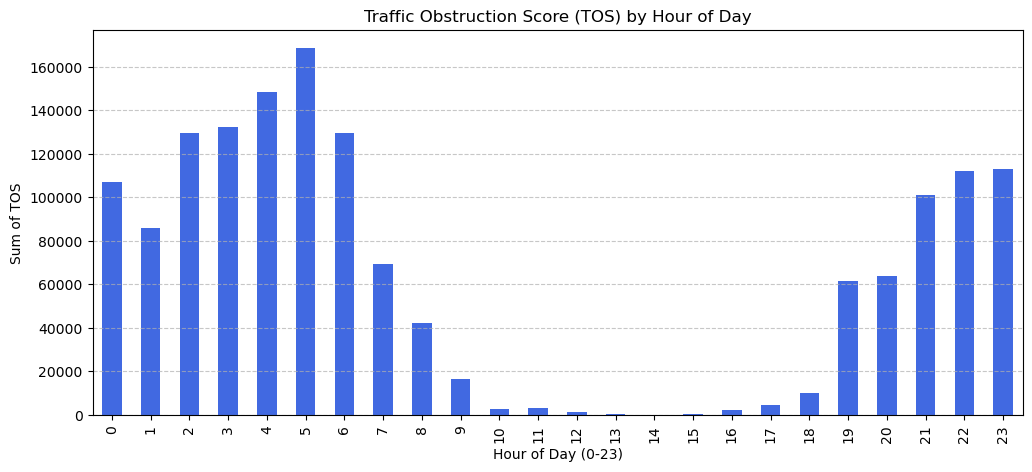

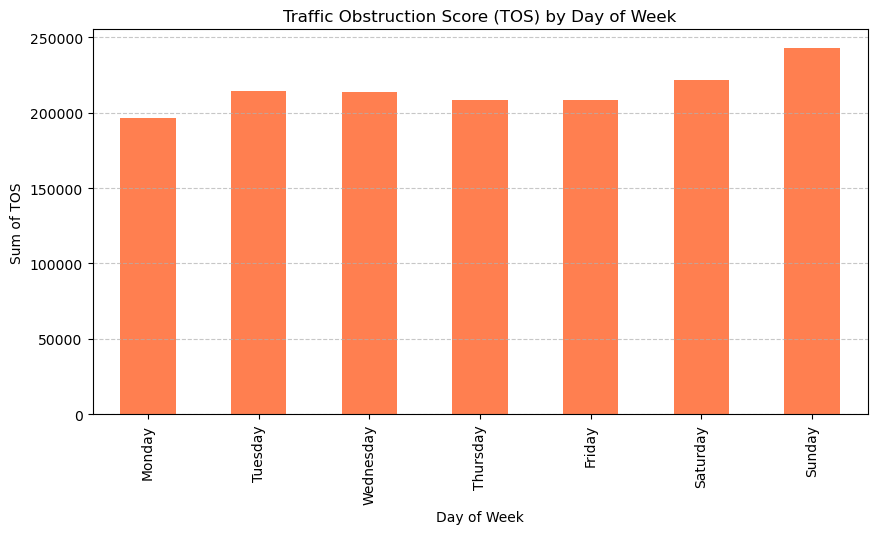

In [9]:
df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.dayofweek
df['day_name'] = df['created_datetime'].dt.day_name()

print(f"Date Range in Dataset: {df['created_datetime'].min()} to {df['created_datetime'].max()}")

# Plot hourly TOS summation
plt.figure(figsize=(12, 5))
df.groupby('hour')['TOS'].sum().plot(kind='bar', color='royalblue')
plt.title('Traffic Obstruction Score (TOS) by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Sum of TOS')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Plot daily TOS summation
plt.figure(figsize=(10, 5))
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df.groupby('day_name')['TOS'].sum().reindex(day_order).plot(kind='bar', color='coral')
plt.title('Traffic Obstruction Score (TOS) by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Sum of TOS')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2b. Timezone Correction: UTC vs. Indian Standard Time (IST)
Because the dataset timestamps are saved with a `+00` offset (UTC), we convert them to local time (`Asia/Kolkata`, which is `+05:30`) to analyze real-world traffic patterns.

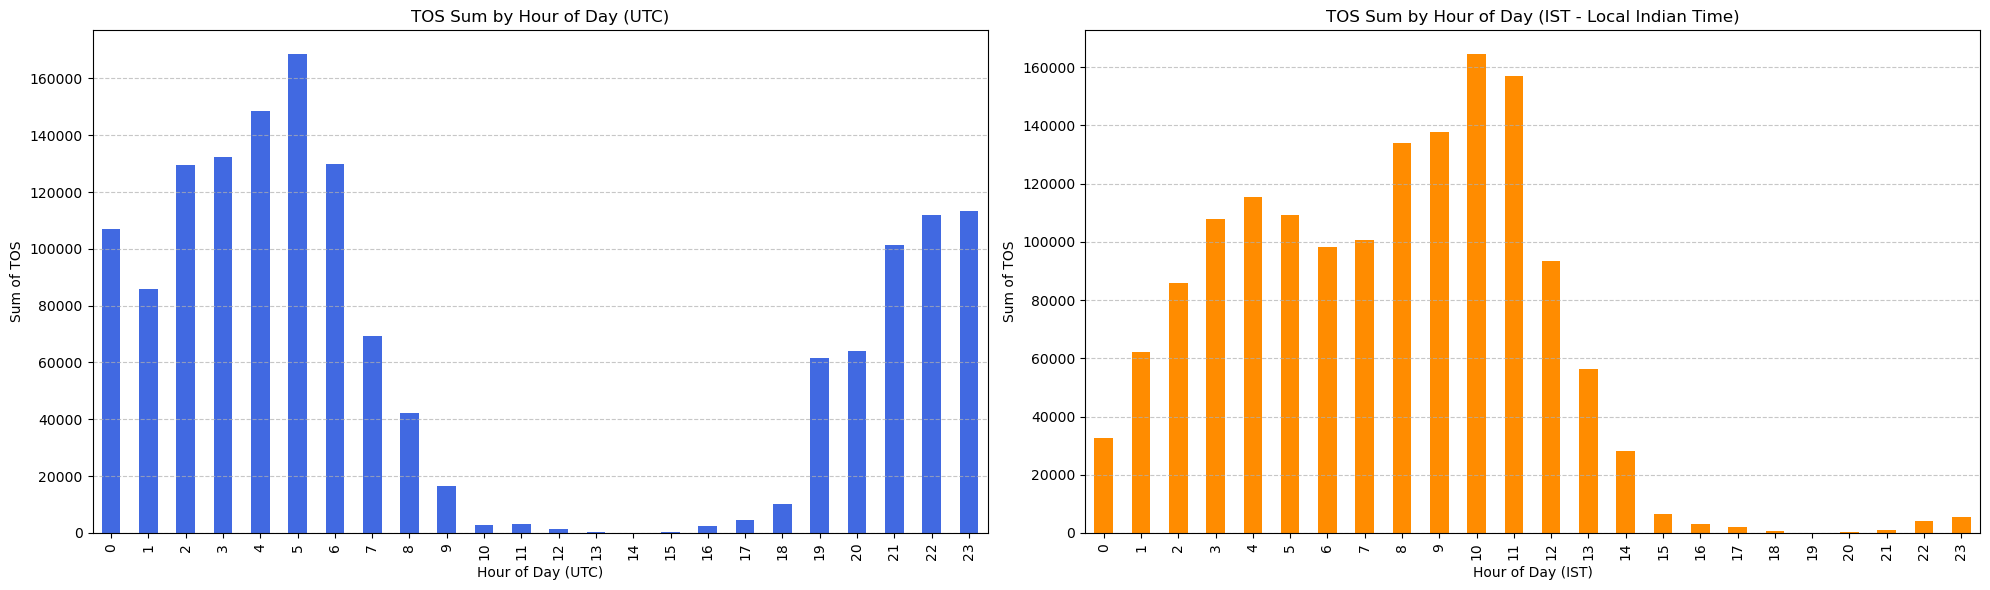

--- Hourly Violations count in local IST ---
hour_ist
0      5815
1     11098
2     16261
3     21565
4     23513
5     22193
6     19838
7     19445
8     25790
9     26996
10    32580
11    32176
12    19689
13    11546
14     5634
15     1224
16      583
17      377
18      150
19       27
20       42
21      148
22      725
23     1035
Name: count, dtype: int64


In [10]:
# Convert timezone-aware datetimes to IST
df['created_datetime_ist'] = df['created_datetime'].dt.tz_convert('Asia/Kolkata')
df['hour_ist'] = df['created_datetime_ist'].dt.hour
df['day_ist'] = df['created_datetime_ist'].dt.day_name()

# Plot UTC vs IST side-by-side
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# UTC Plot
df.groupby('hour')['TOS'].sum().plot(kind='bar', color='royalblue', ax=axes[0])
axes[0].set_title('TOS Sum by Hour of Day (UTC)')
axes[0].set_xlabel('Hour of Day (UTC)')
axes[0].set_ylabel('Sum of TOS')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# IST Plot
df.groupby('hour_ist')['TOS'].sum().plot(kind='bar', color='darkorange', ax=axes[1])
axes[1].set_title('TOS Sum by Hour of Day (IST - Local Indian Time)')
axes[1].set_xlabel('Hour of Day (IST)')
axes[1].set_ylabel('Sum of TOS')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Print numerical distributions for review
print("--- Hourly Violations count in local IST ---")
print(df['hour_ist'].value_counts().sort_index())

## 3. Spatial Aggregation: Police Stations & Junctions
Let's see which jurisdictions and key junctions are most burdened by parking violations.

In [11]:
# Top Police Stations
top_stations = df.groupby('police_station')['TOS'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).head(10)
print("Top 10 Police Stations by Total TOS:")
print(top_stations)

# Top Junctions
top_junctions = df.groupby('junction_name')['TOS'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).head(10)
print("\nTop 10 Junctions by Total TOS:")
print(top_junctions)

Top 10 Police Stations by Total TOS:
                 count       sum      mean
police_station                            
Upparpet         34468  206297.0  5.985175
Shivajinagar     28044  152039.5  5.421463
Malleshwaram     22200  108878.5  4.904437
HAL Old Airport  20819   95256.0  4.575436
City Market      17646   93070.0  5.274283
Vijayanagara     14652   77136.0  5.264537
Rajajinagar      10998   60580.5  5.508320
Magadi Road       8558   42459.0  4.961323
Kodigehalli      10916   40407.0  3.701631
Halasuru Gate     6294   35732.5  5.677232

Top 10 Junctions by Total TOS:
                                     count       sum      mean
junction_name                                                 
No Junction                         147880  632519.0  4.277245
BTP051 - Safina Plaza Junction       15449   88981.5  5.759693
BTP082 - KR Market Junction          11538   61555.5  5.335023
BTP044 - Sagar Theatre Junction      10549   61138.5  5.795668
BTP040 - Elite Junction              

## 4. Vehicle Types & Violation Breakdown
Let's examine which vehicles and specific violation types are most frequent.

Vehicle Types contributing to TOS:
                     count       sum      mean
vehicle_type                                  
CAR                  88870  567537.5  6.386154
SCOOTER              94856  379284.0  3.998524
PASSENGER AUTO       37813  204113.0  5.397958
MOTOR CYCLE          40811  157891.0  3.868834
MAXI-CAB             11372   67975.5  5.977445
LGV                   8255   33537.5  4.062689
GOODS AUTO            2934   16469.0  5.613156
PRIVATE BUS           1633   15317.0  9.379669
BUS (BMTC/KSRTC)      1281   10969.0  8.562842
MOPED                 2199    9353.0  4.253297
TEMPO                 1368    9042.0  6.609649
JEEP                   913    6043.0  6.618839
VAN                   1466    5978.5  4.078104
LORRY/GOODS VEHICLE   1122    4563.5  4.067291
HGV                   1144    4511.5  3.943619


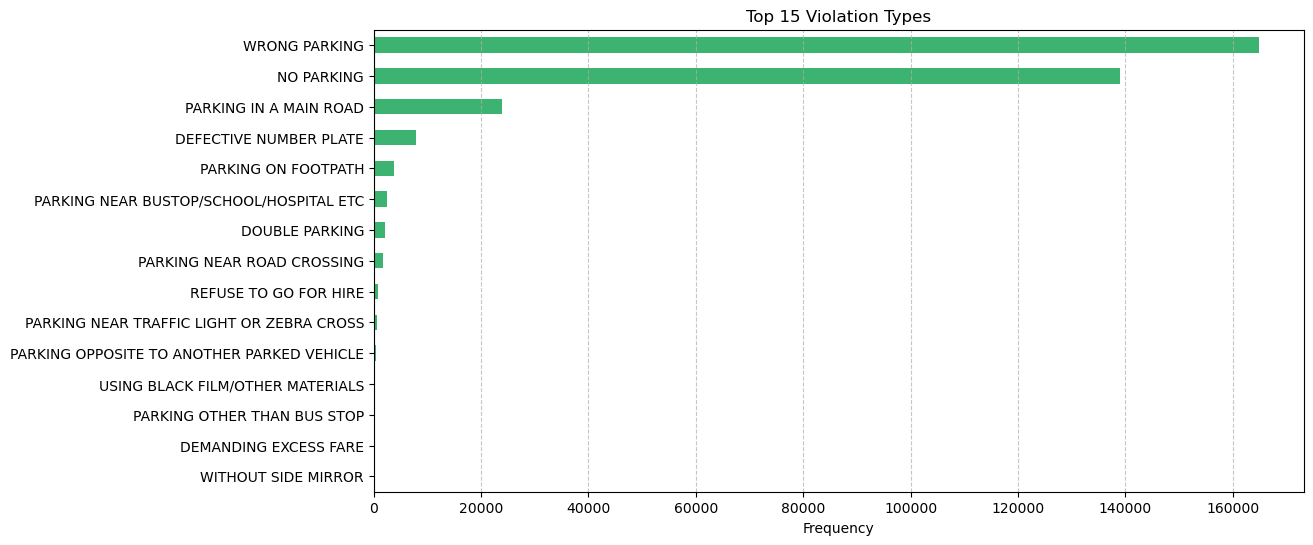

In [12]:
# Vehicle type summary
vehicle_summary = df.groupby('vehicle_type')['TOS'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False)
print("Vehicle Types contributing to TOS:")
print(vehicle_summary.head(15))

# Top violation types
all_violations_flat = [v for sublist in df['parsed_violations'] for v in sublist]
violation_counts = pd.Series(all_violations_flat).value_counts()

plt.figure(figsize=(12, 6))
violation_counts.head(15).plot(kind='barh', color='mediumseagreen')
plt.gca().invert_yaxis()
plt.title('Top 15 Violation Types')
plt.xlabel('Frequency')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 5. Spatial Hotspot Clustering Using DBSCAN
Here, we demonstrate how we cluster coordinates to isolate distinct spatial hotspot areas. We use a haversine distance metric to group coordinates within a 100-meter radius.

In [13]:
from sklearn.cluster import DBSCAN

# Drop NaN coordinates
spatial_df = df.dropna(subset=['latitude', 'longitude']).copy()

# Take a random sample of 50,000 for quick testing and visualization
sample_df = spatial_df.sample(50000, random_state=42).copy()

# Radius threshold: 100 meters (converted to radians for haversine)
kms_per_radian = 6371.0088
epsilon_meters = 100
epsilon_rad = (epsilon_meters / 1000.0) / kms_per_radian

# Run DBSCAN
print("Running DBSCAN clustering on 50,000 sample points...")
db = DBSCAN(eps=epsilon_rad, min_samples=15, metric='haversine', algorithm='ball_tree')

# Haversine expects radians in the order [latitude, longitude]
coords_rad = np.radians(sample_df[['latitude', 'longitude']].values)
sample_df['cluster'] = db.fit_predict(coords_rad)

n_clusters = len(set(sample_df['cluster'])) - (1 if -1 in sample_df['cluster'] else 0)
noise_pct = 100 * (sample_df['cluster'] == -1).sum() / len(sample_df)
print(f"Clusters detected: {n_clusters}")
print(f"Noise points: {noise_pct:.2f}%")

# Top clusters
top_clusters = sample_df[sample_df['cluster'] != -1].groupby('cluster').agg(
    lat_center=('latitude', 'mean'),
    lon_center=('longitude', 'mean'),
    tos_total=('TOS', 'sum'),
    violations_count=('cluster', 'count')
).sort_values(by='tos_total', ascending=False).head(10)

print("\nTop 10 Hotspot Clusters (Sample Data):")
print(top_clusters)

Running DBSCAN clustering on 50,000 sample points...
Clusters detected: 235
Noise points: 10.48%

Top 10 Hotspot Clusters (Sample Data):
         lat_center  lon_center  tos_total  violations_count
cluster                                                     
13        12.972615   77.577439    56183.0              9710
0         12.981983   77.608038    23363.0              4268
7         12.999167   77.549264     9121.5              1626
4         13.010296   77.553377     8465.0              1701
14        12.933388   77.690167     7029.0              1733
22        12.974508   77.547308     6723.0              1400
36        12.989534   77.553222     4669.5               720
57        13.185561   77.680123     4243.0               796
43        12.967088   77.537937     4163.0               795
16        12.995743   77.571673     4116.5               990


## 5. Spatial Hotspot Clustering (Full Dataset)
We run DBSCAN clustering on all valid coordinates in the dataset using the production parameters (150m radius, minimum 30 violations) to establish the canonical hotspot zones (`spot_id`).

In [ ]:
from sklearn.cluster import DBSCAN

# Drop coordinates with missing values
spatial_df = df.dropna(subset=['latitude', 'longitude']).copy()

# Setup DBSCAN parameters matching backend configuration
kms_per_radian = 6371.0088
epsilon_meters = 150  # 150m radius threshold
epsilon_rad = (epsilon_meters / 1000.0) / kms_per_radian

print("Running DBSCAN clustering on the entire spatial dataset...")
db = DBSCAN(eps=epsilon_rad, min_samples=30, metric='haversine', algorithm='ball_tree')

coords_rad = np.radians(spatial_df[['latitude', 'longitude']].values)
spatial_df['spot_id'] = db.fit_predict(coords_rad)

n_spots = len(spatial_df[spatial_df['spot_id'] != -1]['spot_id'].unique())
noise_pct = 100 * (spatial_df['spot_id'] == -1).sum() / len(spatial_df)
print(f"Total Hotspot Clusters Detected: {n_spots}")
print(f"Noise Points (violations not in any hotspot): {noise_pct:.2f}%")

## 6. Hourly Time-Series Aggregation & Target Normalization (0-100% Index)
To formulate our time-series forecasting model, we structure the violations data into a continuous hourly timeline for each hotspot. The target variable is the hourly sum of raw Traffic Obstruction Scores (TOS).
To normalize the target across spots, we scale the raw TOS into a **Congestion Risk Index (0-100%)** based on the 99th percentile of raw TOS in the training set. This prevents outlier squashing while keeping predictions within a standard percentage scale.

In [ ]:
# 1. Extract cluster centroids and group meta
hotspots_df = spatial_df[spatial_df['spot_id'] != -1].copy()
centroids = hotspots_df.groupby('spot_id').agg(
    latitude=('latitude', 'mean'),
    longitude=('longitude', 'mean'),
    police_station=('police_station', lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Convert datetime to local IST timezone
hotspots_df['created_datetime'] = hotspots_df['created_datetime'].dt.tz_convert('Asia/Kolkata')
hotspots_df['hour_bin'] = hotspots_df['created_datetime'].dt.floor('h')

min_time = hotspots_df['hour_bin'].min()
max_time = hotspots_df['hour_bin'].max()
all_hours = pd.date_range(start=min_time, end=max_time, freq='h', tz='Asia/Kolkata')

print(f"Timeline ranges from {min_time} to {max_time} ({len(all_hours)} hours)")

# Reconstruct a continuous timeline for each spot to capture periods of zero violations
idx = pd.MultiIndex.from_product([hotspots_df['spot_id'].unique(), all_hours], names=['spot_id', 'hour_bin'])
timeline_df = pd.DataFrame(index=idx).reset_index()

# Group raw violations by spot and hour, summing the count and raw TOS
hourly_agg = hotspots_df.groupby(['spot_id', 'hour_bin']).agg(
    violations_count=('id', 'count'),
    raw_tos=('TOS', 'sum')
).reset_index()

# Merge aggregated violations back into the timeline
timeline_df = pd.merge(timeline_df, hourly_agg, on=['spot_id', 'hour_bin'], how='left')
timeline_df['violations_count'] = timeline_df['violations_count'].fillna(0)
timeline_df['raw_tos'] = timeline_df['raw_tos'].fillna(0.0)

# Merge coordinates metadata
timeline_df = pd.merge(timeline_df, centroids, on='spot_id', how='left')

# Chronological split definitions (70% Train, 15% Val, 15% Test)
total_hours = len(all_hours)
train_end_idx = int(total_hours * 0.70)
train_cutoff = all_hours[train_end_idx]

print(f"Training split cutoff timestamp: {train_cutoff}")

# Target scaling: Find the 99th percentile of raw TOS in the training set
train_mask = timeline_df['hour_bin'] < train_cutoff
tos_99 = timeline_df[train_mask]['raw_tos'].quantile(0.99)
if tos_99 == 0:
    tos_99 = 1.0

print(f"99th percentile of raw TOS in Training set: {tos_99:.2f} (used as 100% capacity threshold)")

# Normalize target to Congestion Risk Index (0-100%)
timeline_df['congestion_index'] = np.minimum(100.0, (timeline_df['raw_tos'] / tos_99) * 100.0)
print("\nCongestion Risk Index Summary Statistics:")
print(timeline_df['congestion_index'].describe())

## 7. Feature Engineering (Calendar & Dynamic Lags)
To capture seasonal patterns and the autocorrelation of traffic violations, we construct calendar and lag features. 
Lags are calculated using `shift` to ensure that when predicting for an hour, the model only has access to past information (preventing lookahead bias). We compute:
* `hour_of_day`, `day_of_week`, `is_weekend` (calendar features)
* `prev_day_TOS` (congestion risk exactly 24 hours ago)
* `prev_week_TOS` (congestion risk exactly 168 hours ago)
* `rolling_TOS_24h` (rolling mean of congestion risk over the previous 24 hours)

We drop the first 7 days of the timeline because they do not have a full week of history to build the 168-hour lag. This ensures that every sample evaluated has a fully populated set of lag features, reflecting real-world inference robustness.
Finally, we compute baseline average risks (e.g. `spot_avg_TOS` and `spot_hour_weekday_avg_TOS`) using training records only.

In [ ]:
# Sort timeline chronologically to ensure accurate shifts
timeline_df = timeline_df.sort_values(by=['spot_id', 'hour_bin']).reset_index(drop=True)

# Calendar features
timeline_df['hour_of_day'] = timeline_df['hour_bin'].dt.hour
timeline_df['day_of_week'] = timeline_df['hour_bin'].dt.dayofweek
timeline_df['is_weekend'] = (timeline_df['day_of_week'] >= 5).astype(int)

# Dynamic time-series lags (shift by hours)
timeline_df['prev_day_TOS'] = timeline_df.groupby('spot_id')['congestion_index'].shift(24)
timeline_df['prev_week_TOS'] = timeline_df.groupby('spot_id')['congestion_index'].shift(168)
timeline_df['rolling_TOS_24h'] = timeline_df.groupby('spot_id')['congestion_index'].shift(1).rolling(24).mean()

# Drop rows at the beginning of the timeline that lack complete history
timeline_df_clean = timeline_df.dropna(subset=['prev_week_TOS', 'rolling_TOS_24h']).copy()

# Compute target encodings using training data ONLY to avoid data leakage
train_data = timeline_df_clean[timeline_df_clean['hour_bin'] < train_cutoff]

# Spot average risk
spot_train_avg = train_data.groupby('spot_id')['congestion_index'].mean().to_dict()
timeline_df_clean['spot_avg_TOS'] = timeline_df_clean['spot_id'].map(spot_train_avg).fillna(0.0)

# Spot average risk grouped by hour of day and day of week
spot_hw_train_avg = train_data.groupby(['spot_id', 'hour_of_day', 'day_of_week'])['congestion_index'].mean().reset_index()
spot_hw_train_avg.rename(columns={'congestion_index': 'spot_hour_weekday_avg_TOS'}, inplace=True)

timeline_df_clean = pd.merge(timeline_df_clean, spot_hw_train_avg, on=['spot_id', 'hour_of_day', 'day_of_week'], how='left')
timeline_df_clean['spot_hour_weekday_avg_TOS'] = timeline_df_clean['spot_hour_weekday_avg_TOS'].fillna(timeline_df_clean['spot_avg_TOS'])

print(f"Cleaned dataset shape after lag engineering: {timeline_df_clean.shape}")

## 8. Model Training & Chronological Splits
We partition the dataset chronologically:
* **Train Set**: Before `train_cutoff` (70% of historical timeline)
* **Validation Set**: From `train_cutoff` to `val_cutoff` (15%)
* **Test Set**: From `val_cutoff` onwards (15%)

We then fit a RandomForestRegressor to predict the Congestion Risk Index.

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = [
    'hour_of_day', 'day_of_week', 'is_weekend', 
    'spot_avg_TOS',
    'prev_day_TOS', 'prev_week_TOS', 'rolling_TOS_24h'
]
target = 'congestion_index'

# Determine validation split cutoff
val_end_idx = int(total_hours * 0.85)
val_cutoff = all_hours[val_end_idx]

print(f"Validation split cutoff timestamp: {val_cutoff}")

train_split = timeline_df_clean[timeline_df_clean['hour_bin'] < train_cutoff]
val_split = timeline_df_clean[(timeline_df_clean['hour_bin'] >= train_cutoff) & (timeline_df_clean['hour_bin'] < val_cutoff)]
test_split = timeline_df_clean[timeline_df_clean['hour_bin'] >= val_cutoff]

X_train, y_train = train_split[features], train_split[target]
X_val, y_val = val_split[features], val_split[target]
X_test, y_test = test_split[features], test_split[target]

print(f"Train size: {X_train.shape[0]} samples")
print(f"Val size:   {X_val.shape[0]} samples")
print(f"Test size:  {X_test.shape[0]} samples")

print("\nTraining RandomForest Regressor...")
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print("Model training complete.")

Validation split cutoff timestamp: 2024-03-17 08:00:00+05:30
Train size: 632256 samples
Val size:   145248 samples
Test size:  145248 samples

Training RandomForest Regressor...
Model training complete.


## 9. Feature Importances, Robust Baseline Metrics & Hurdle Threshold Evaluation
Because 96.32% of our spot-hour timeline has exactly 0 violations (due to selective police enforcement and daily cycles), evaluating the model on the full set in a vacuum is highly misleading. A dummy model predicting `0` all the time achieves an overall accuracy of **96.41%** and MAE of **1.79%**.
To evaluate our model robustly, we compute and print:
1. **Full Set Evaluation**: Standard metrics (MAE, RMSE, R²) and custom Accuracy (within 2% and 5% tolerance) for the **Zero-Prediction Baseline**, the **Raw Random Forest**, and the **Hurdle-Thresholded Random Forest** (rounding predictions < 5% to 0.0%).
2. **Active-Hours Evaluation**: MAE for all three models evaluated strictly on hours with non-zero violations (where actual risk > 0.0%).
3. **Active-Hour Classification Metrics**: Precision, Recall, and F1-score for detecting active congestion using a 5.0% prediction threshold.

We also plot the feature importances and run out-of-sample prediction checks.

--- Full Set Evaluation Metrics ---

Train      Set Evaluation:
  Zero-Baseline:      MAE = 1.88%, Accuracy (within 2%): 96.26%, Accuracy (within 5%): 96.26%
  Raw Model:          MAE = 1.97%, Accuracy (within 2%): 85.77%, Accuracy (within 5%): 92.32%
  Thresholded (5%):   MAE = 1.55%, Accuracy (within 2%): 92.04%, Accuracy (within 5%): 92.31%

Validation Set Evaluation:
  Zero-Baseline:      MAE = 1.83%, Accuracy (within 2%): 96.43%, Accuracy (within 5%): 96.43%
  Raw Model:          MAE = 2.17%, Accuracy (within 2%): 85.38%, Accuracy (within 5%): 91.97%
  Thresholded (5%):   MAE = 1.75%, Accuracy (within 2%): 91.77%, Accuracy (within 5%): 91.95%

Test       Set Evaluation:
  Zero-Baseline:      MAE = 1.78%, Accuracy (within 2%): 96.46%, Accuracy (within 5%): 96.46%
  Raw Model:          MAE = 2.09%, Accuracy (within 2%): 85.39%, Accuracy (within 5%): 92.15%
  Thresholded (5%):   MAE = 1.67%, Accuracy (within 2%): 91.91%, Accuracy (within 5%): 92.14%

--- Evaluation on Active Hours On

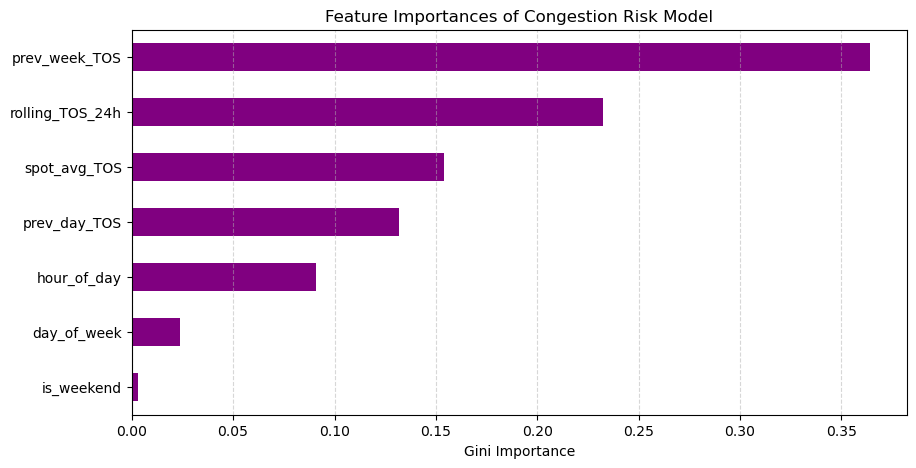


--- Out of Sample Dynamic Inference Check ---
Date: 2024-04-01T10:00:00 | Spot 0 predicted risk: 3.98% (Rolling 24h average input: 0.95%)
Date: 2024-04-08T10:00:00 | Spot 0 predicted risk: 8.66% (Rolling 24h average input: 6.44%)


In [23]:
# 1. Evaluation Metrics
print("--- Full Set Evaluation Metrics ---")
for name, X, y in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    preds = rf.predict(X)
    preds_clipped = np.clip(preds, 0.0, 100.0)
    
    # Zero baseline
    zero_preds = np.zeros_like(y)
    mae_zero = mean_absolute_error(y, zero_preds)
    acc_2_zero = np.mean(np.abs(y - zero_preds) < 2.0) * 100
    acc_5_zero = np.mean(np.abs(y - zero_preds) < 5.0) * 100
    
    # Raw model
    mae_raw = mean_absolute_error(y, preds_clipped)
    acc_2_raw = np.mean(np.abs(y - preds_clipped) < 2.0) * 100
    acc_5_raw = np.mean(np.abs(y - preds_clipped) < 5.0) * 100
    
    # Thresholded model (hurdle @ 5.0%)
    preds_thresh = np.where(preds_clipped < 5.0, 0.0, preds_clipped)
    mae_thresh = mean_absolute_error(y, preds_thresh)
    acc_2_thresh = np.mean(np.abs(y - preds_thresh) < 2.0) * 100
    acc_5_thresh = np.mean(np.abs(y - preds_thresh) < 5.0) * 100
    
    print(f"\n{name:10} Set Evaluation:")
    print(f"  Zero-Baseline:      MAE = {mae_zero:.2f}%, Accuracy (within 2%): {acc_2_zero:.2f}%, Accuracy (within 5%): {acc_5_zero:.2f}%")
    print(f"  Raw Model:          MAE = {mae_raw:.2f}%, Accuracy (within 2%): {acc_2_raw:.2f}%, Accuracy (within 5%): {acc_5_raw:.2f}%")
    print(f"  Thresholded (5%):   MAE = {mae_thresh:.2f}%, Accuracy (within 2%): {acc_2_thresh:.2f}%, Accuracy (within 5%): {acc_5_thresh:.2f}%")

# 2. Evaluation on Active Hours only (y_true > 0)
print("\n--- Evaluation on Active Hours Only (Actual Congestion > 0) ---")
for name, X, y in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    preds = rf.predict(X)
    preds_clipped = np.clip(preds, 0.0, 100.0)
    preds_thresh = np.where(preds_clipped < 5.0, 0.0, preds_clipped)
    
    active_mask = y > 0
    y_active = y[active_mask]
    preds_active_raw = preds_clipped[active_mask]
    preds_active_thresh = preds_thresh[active_mask]
    
    if len(y_active) > 0:
        mae_active_zero = mean_absolute_error(y_active, np.zeros_like(y_active))
        mae_active_raw = mean_absolute_error(y_active, preds_active_raw)
        mae_active_thresh = mean_absolute_error(y_active, preds_active_thresh)
        print(f"\n{name:10} Set (Active Hours: {len(y_active)} samples):")
        print(f"  Zero-Baseline MAE: {mae_active_zero:.2f}%")
        print(f"  Raw Model MAE:     {mae_active_raw:.2f}%")
        print(f"  Thresholded MAE:   {mae_active_thresh:.2f}%")

# 3. Active Hour Classification Metrics (threshold @ 5%)
from sklearn.metrics import precision_score, recall_score, f1_score
print("\n--- Active Congestion Detection Metrics (Predicted > 5.0% vs Actual > 0.0%) ---")
for name, X, y in [("Train", X_train, y_train), ("Validation", X_val, y_val), ("Test", X_test, y_test)]:
    preds = rf.predict(X)
    y_true_binary = (y > 0).astype(int)
    y_pred_binary = (preds > 5.0).astype(int)
    
    prec = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    rec = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    
    print(f"\n{name:10} Set Detection:")
    print(f"  Precision: {prec*100:.2f}%")
    print(f"  Recall:    {rec*100:.2f}%")
    print(f"  F1-Score:  {f1*100:.2f}%")

# 4. Plot Feature Importances
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='purple')
plt.title('Feature Importances of Congestion Risk Model')
plt.xlabel('Gini Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

# 5. Dynamic Inference Check: Compare predicted values for Spot 0 across different dates at 10:00 AM
print("\n--- Out of Sample Dynamic Inference Check ---")
spot_id = 0
test_dates = ["2024-04-01T10:00:00", "2024-04-08T10:00:00"]
spot_avg = spot_train_avg.get(spot_id, 0.0)

for dt_str in test_dates:
    q_dt = pd.to_datetime(dt_str).tz_localize(None).tz_localize('Asia/Kolkata')
    
    # Look up weekly average for Monday 10:00 AM
    hw_rows = timeline_df_clean[(timeline_df_clean['spot_id'] == spot_id) & (timeline_df_clean['hour_of_day'] == 10) & (timeline_df_clean['day_of_week'] == 0)]
    spot_hw_avg = float(hw_rows['spot_hour_weekday_avg_TOS'].iloc[0]) if not hw_rows.empty else spot_avg
    
    # Look up lags for query date
    prev_day_dt = q_dt - pd.Timedelta(days=1)
    prev_day_rows = timeline_df_clean[(timeline_df_clean['spot_id'] == spot_id) & (timeline_df_clean['hour_bin'] == prev_day_dt)]
    prev_day_val = float(prev_day_rows['congestion_index'].iloc[0]) if not prev_day_rows.empty else spot_hw_avg
    
    prev_week_dt = q_dt - pd.Timedelta(days=7)
    prev_week_rows = timeline_df_clean[(timeline_df_clean['spot_id'] == spot_id) & (timeline_df_clean['hour_bin'] == prev_week_dt)]
    prev_week_val = float(prev_week_rows['congestion_index'].iloc[0]) if not prev_week_rows.empty else spot_hw_avg

    # Look up 24h rolling average
    rolling_start = q_dt - pd.Timedelta(hours=24)
    rolling_end = q_dt - pd.Timedelta(hours=1)
    rolling_rows = timeline_df_clean[(timeline_df_clean['spot_id'] == spot_id) & (timeline_df_clean['hour_bin'] >= rolling_start) & (timeline_df_clean['hour_bin'] <= rolling_end)]
    rolling_val = float(rolling_rows['congestion_index'].mean()) if not rolling_rows.empty else spot_hw_avg

    # Format input DataFrame with proper column names
    input_df = pd.DataFrame([[
        10, 0, 0, # hour, day_of_week (Mon), is_weekend
        spot_avg,
        prev_day_val, prev_week_val, rolling_val
    ]], columns=features)
    
    pred = rf.predict(input_df)[0]
    print(f"Date: {dt_str} | Spot 0 predicted risk: {pred:.2f}% (Rolling 24h average input: {rolling_val:.2f}%)")